Video wird erstellt...
Video gespeichert unter:
../Video_Animation/carbon_atom_evolution.mp4


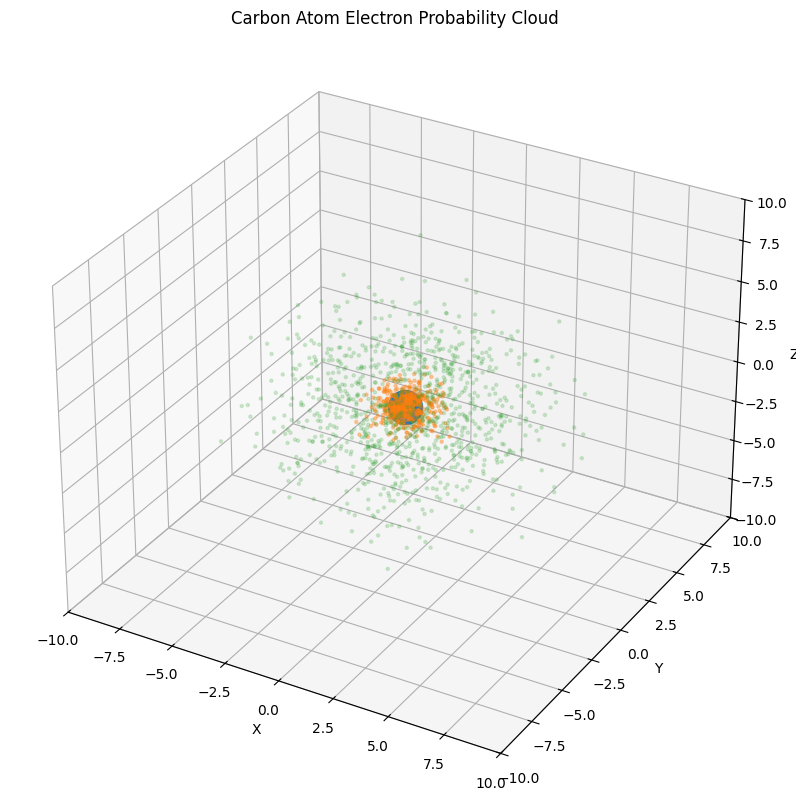

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

# ==========================================
# CARBON ATOM EVOLUTION
# ==========================================

OUTPUT_VIDEO = "../Video_Animation/carbon_atom_evolution.mp4"

# ==========================================
# Einstellungen
# ==========================================

fps = 30

frames_shell_1 = 250
frames_shell_2 = 250

total_frames = frames_shell_1 + frames_shell_2

limit = 10

# ==========================================
# Figure
# ==========================================

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# ==========================================
# Positionsspeicher
# ==========================================

shell1_positions = []
shell2_positions = []

# ==========================================
# 1s Orbital
# ==========================================

def sample_1s():

    while True:

        x = np.random.normal(0, 1.0)
        y = np.random.normal(0, 1.0)
        z = np.random.normal(0, 1.0)

        r = np.sqrt(x**2 + y**2 + z**2)

        probability = np.exp(-2 * r)

        if np.random.rand() < probability:
            return x, y, z

# ==========================================
# 2s / 2p Bereich
# ==========================================

def sample_2nd_shell():

    while True:

        x = np.random.normal(0, 2.5)
        y = np.random.normal(0, 2.5)
        z = np.random.normal(0, 2.5)

        r = np.sqrt(x**2 + y**2 + z**2)

        probability = (r**2) * np.exp(-r / 2)

        probability = probability / 10

        if np.random.rand() < probability:
            return x, y, z

# ==========================================
# Animation
# ==========================================

def update(frame):

    ax.clear()

    # ======================================
    # Atomkern
    # ======================================

    ax.scatter(
        0,
        0,
        0,
        s=600
    )

    # ======================================
    # PHASE 1
    # Erste Schale
    # ======================================

    if frame < frames_shell_1:

        for _ in range(2):

            shell1_positions.append(
                sample_1s()
            )

    # ======================================
    # PHASE 2
    # Zweite Schale kommt hinzu
    # ======================================

    else:

        for _ in range(4):

            shell2_positions.append(
                sample_2nd_shell()
            )

    # ======================================
    # Erste Schale zeichnen
    # ======================================

    if len(shell1_positions) > 0:

        p1 = np.array(shell1_positions)

        ax.scatter(
            p1[:,0],
            p1[:,1],
            p1[:,2],
            s=5,
            alpha=0.35
        )

    # ======================================
    # Zweite Schale zeichnen
    # ======================================

    if len(shell2_positions) > 0:

        p2 = np.array(shell2_positions)

        ax.scatter(
            p2[:,0],
            p2[:,1],
            p2[:,2],
            s=5,
            alpha=0.18
        )

    # ======================================
    # Achsen
    # ======================================

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)

    ax.set_title("Carbon Atom Electron Probability Cloud")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

# ==========================================
# Animation erstellen
# ==========================================

ani = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    interval=1000 / fps
)

# ==========================================
# Video speichern
# ==========================================

print("Video wird erstellt...")

ani.save(
    OUTPUT_VIDEO,
    writer="ffmpeg",
    fps=fps
)

print("Video gespeichert unter:")
print(OUTPUT_VIDEO)